## Read output files

In [4]:
import awkward as ak
import numpy as np
import uproot
import os

In [24]:
basedir = {
    c: '../condor/output/mc/2018/'+c for c in os.listdir('../condor/output/mc/2018/')
}
filepath={c: [] for c in basedir}
for c in basedir:
    for (current_path, dirs, files) in os.walk(basedir[c]):
        for f in files:
            if f.endswith('.parq'):
                filepath[c].append(os.path.join(current_path, f))

filepath

{'GJets': ['../condor/output/mc/2018/GJets/GJets_HT-100To200_TuneCP5/0.parq',
  '../condor/output/mc/2018/GJets/GJets_HT-100To200_TuneCP5/1.parq',
  '../condor/output/mc/2018/GJets/GJets_HT-100To200_TuneCP5/10.parq',
  '../condor/output/mc/2018/GJets/GJets_HT-100To200_TuneCP5/11.parq',
  '../condor/output/mc/2018/GJets/GJets_HT-100To200_TuneCP5/12.parq',
  '../condor/output/mc/2018/GJets/GJets_HT-100To200_TuneCP5/13.parq',
  '../condor/output/mc/2018/GJets/GJets_HT-100To200_TuneCP5/14.parq',
  '../condor/output/mc/2018/GJets/GJets_HT-100To200_TuneCP5/15.parq',
  '../condor/output/mc/2018/GJets/GJets_HT-100To200_TuneCP5/16.parq',
  '../condor/output/mc/2018/GJets/GJets_HT-100To200_TuneCP5/17.parq',
  '../condor/output/mc/2018/GJets/GJets_HT-100To200_TuneCP5/18.parq',
  '../condor/output/mc/2018/GJets/GJets_HT-100To200_TuneCP5/19.parq',
  '../condor/output/mc/2018/GJets/GJets_HT-100To200_TuneCP5/2.parq',
  '../condor/output/mc/2018/GJets/GJets_HT-100To200_TuneCP5/20.parq',
  '../condor/o

In [25]:
events = {
    k: [] for k in filepath
}
for k, v in filepath.items():
    for f in v:
        array = ak.from_parquet(f)
        if len(array)>0:
            events[k].append(array)
    events[k] = ak.concatenate(events[k], axis=0)

events

{'GJets': <Array [{AK8jet_pt: 311, ... ] type='468039 * {"AK8jet_pt": float32, "AK8jet_mas...'>,
 'QCD': <Array [{AK8jet_msoftdrop: 238, ... ] type='17364 * {"AK8jet_msoftdrop": float32...'>,
 'WJetsToQQ': <Array [{AK8jet_phi: 0.749, ... ] type='8227 * {"AK8jet_phi": float32, "AK8jet_m...'>,
 'ZJetsToQQ': <Array [{AK8jet_eta: -0.138, ... ] type='2350 * {"AK8jet_eta": float32, "AK8jet_...'>,
 'ZpToHGamma': <Array [{AK8jet_msoftdrop: 117, ... ] type='173452 * {"AK8jet_msoftdrop": float3...'>}

## Start plotting

In [26]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import mplhep as hep
import boost_histogram as bh
from cycler import cycler

use_helvet = False ## true: use helvetica for plots, make sure the system have the font installed
if use_helvet:
    CMShelvet = hep.style.CMS
    CMShelvet['font.sans-serif'] = ['Helvetica', 'Arial']
    plt.style.use(CMShelvet)
else:
    plt.style.use(hep.style.CMS)

mpl.rcParams['axes.prop_cycle'] = cycler(color=['red', 'blue', 'green', 'cyan', 'darkorange', 'HotPink', 'darkviolet', 'SlateGray', 'black', 'LightSkyBlue'])

In [27]:
for m in [1000, 2000, 3000]:
    cut = ak.flatten(
        (events['ZpToHGamma']["gen_Zp_mass"] > m-10) &
        (events['ZpToHGamma']["gen_Zp_mass"] < m+10)
    )
    events[f'ZpToHGamma_{m}'] = events['ZpToHGamma'][cut]

del events['ZpToHGamma']

In [40]:
def plot(arrays, x_name: str, cuts=None, year=2018, flatten=False, bins=40, x_min=0, x_max=2000, density=True, stack=False, overflow=True, underflow=False):
    if cuts:
        arrays = {k: v[cuts[k]] for k, v in arrays.items()}    
    
    ## canvas initializing
    #colorlist=['red', 'blue', 'green', 'black', 'cyan', 'darkorange', 'darkviolet', 'SlateGray', 'HotPink', 'LightSkyBlue']
    #mpl.rcParams['axes.prop_cycle'] = cycler(color=colorlist)
    #f, ax = plt.subplots()
    plt.figure(figsize=(8,8))
    ax=plt.gca()
    plt.grid()
    hep.cms.label(data=False, year=year, ax=ax)
    
    ## plot
    for (k,v) in arrays.items():
        hist = bh.Histogram(bh.axis.Regular(bins, x_min, x_max), storage=bh.storage.Weight())
        if flatten:
            v = ak.flatten(v, axis=-1)
        values = ak.fill_none(v, -999)
        
        hist.fill(values)
        h, var = hist.view(flow=overflow).value, hist.view(flow=overflow).variance
        if overflow: ## h, var also include underflow bins but in plots usually no underflow data
            ## And we've filled None with -999, so we shouldn't show underflow data (mostly from filled None)
            h[-2]+=h[-1]; var[-2]+=var[-1]
        if underflow:
            h[1]+=h[0]; var[1]+=var[0]
        if overflow or underflow:
            h = h[1:-1]; var = var[1:-1]
        err = np.sqrt(var)
        hep.histplot(h, bins=hist.axes[0].edges, yerr=err, label=k, histtype='step', density=density, stack=stack)
        # or you can specify color='blue' in the above function to cover colorlist (you could comment out colorlist too) 


    ## axises
    plt.xlim(x_min, x_max)
    plt.ylim(0, ax.get_ylim()[1]*1.25)
    ax.ticklabel_format(useOffset=False, style='plain')
    #x_major_locator=plt.MultipleLocator(bin_width*8 if variable=='fj_gen_mass' else bin_width*2)
    #y_major_locator=MultipleLocator(1)
    #ax.xaxis.set_major_locator(x_major_locator)
    #ax.yaxis.set_major_locator(y_major_locator)
    if density==False:
        plt.ylabel('Events', fontsize=20, ha='right', y=1)
    elif density==True:    
        plt.ylabel('A.U.', fontsize=20, ha='right', y=1)
    plt.xlabel(x_name, fontsize=22, ha='right', x=1)

    plt.xticks(size=16)
    plt.yticks(size=16)


    ## title, text and legend
    #plt.title('ROC Curve of HWW4q vs. QCD', fontsize=24,color="black")
    plt.legend(loc="best", ncol=2, frameon=False, fontsize=18)
    #plt.text(0.96*ax.get_xlim()[1], ax.get_ylim()[1]*0.72,"At "+r"$\mathrm{m^{gen}_{H}=}$"+f"{Higgsmass} GeV", fontsize=24, color="black", ha='right')


    ## finalizing
    suffix = ''
    if density==True:   suffix += '_AU'
    if stack==True:     suffix += '_stack'
    if not os.path.exists('./plots'):
        os.makedirs('./plots')
    plt.savefig("./plots/"+x_name+suffix+".pdf", bbox_inches='tight')
    plt.show()

In [41]:
print(events['ZpToHGamma_1000'].fields)

['AK8jet_msoftdrop', 'AK8jet_pt', 'AK8jet_phi', 'AK8jet_mass', 'AK8jet_eta', 'photon_pt', 'photon_phi', 'photon_eta', 'photon_mass', 'event_MET_pt', 'event_genWeight', 'photon-jet_pt', 'photon-jet_phi', 'photon-jet_eta', 'photon-jet_mass', 'photon-jet_deltaR', 'gen_Zp_pt', 'gen_Zp_phi', 'gen_Zp_mass', 'gen_Zp_pdgId', 'gen_Zp_eta', 'gen_H_pt', 'gen_H_phi', 'gen_H_mass', 'gen_H_pdgId', 'gen_H_eta', 'gen_a_pt', 'gen_a_phi', 'gen_a_mass', 'gen_a_pdgId', 'gen_a_eta', 'gen_WW_pt', 'gen_WW_phi', 'gen_WW_mass', 'gen_WW_pdgId', 'gen_WW_eta', 'gen_WW_childs_pt', 'gen_WW_childs_phi', 'gen_WW_childs_mass', 'gen_WW_childs_pdgId', 'gen_WW_childs_eta', 'gen_H_a', 'gen_deltaR_H_a', 'gen_HWW_decay_mode', 'gen_HWW_a', 'gen_MET_pt']


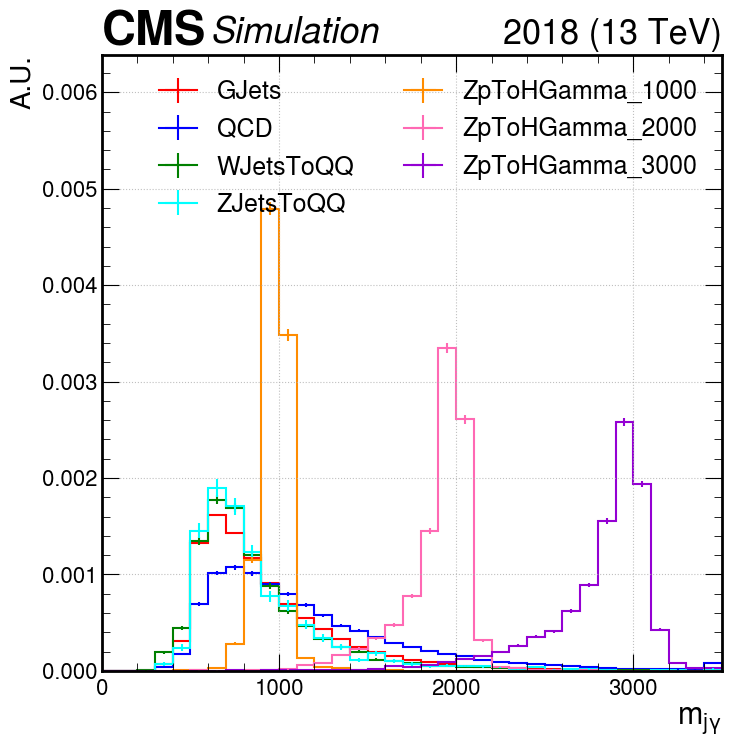

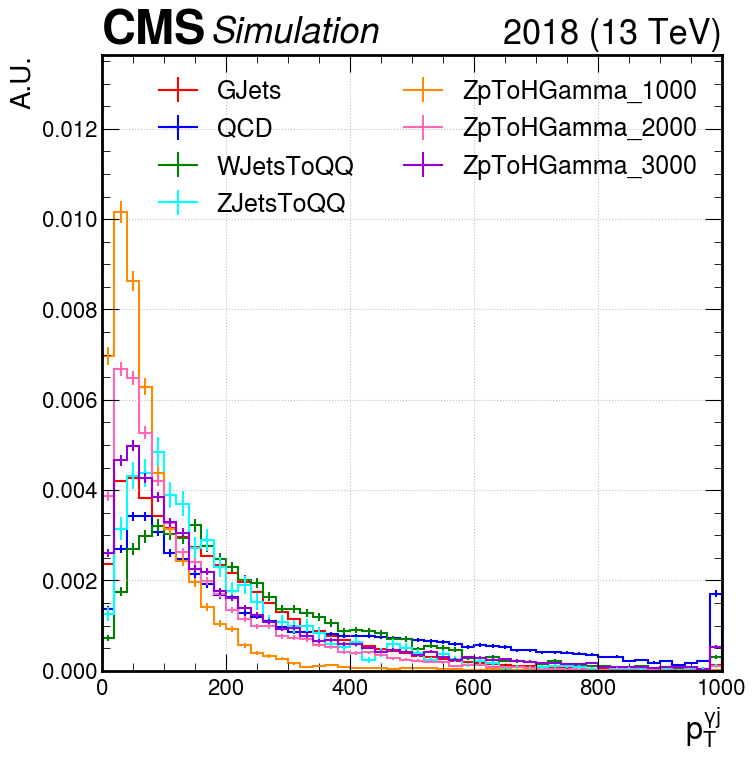

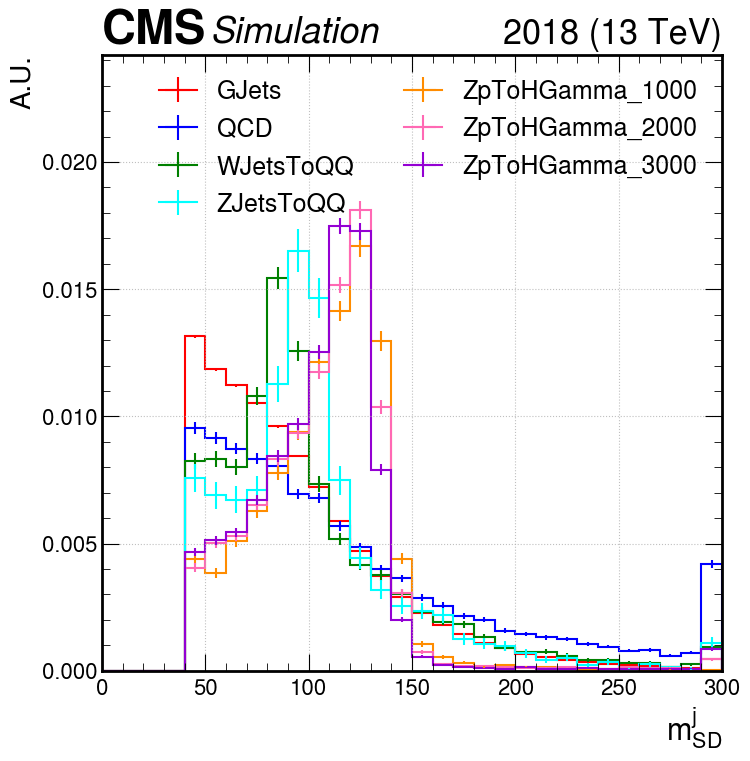

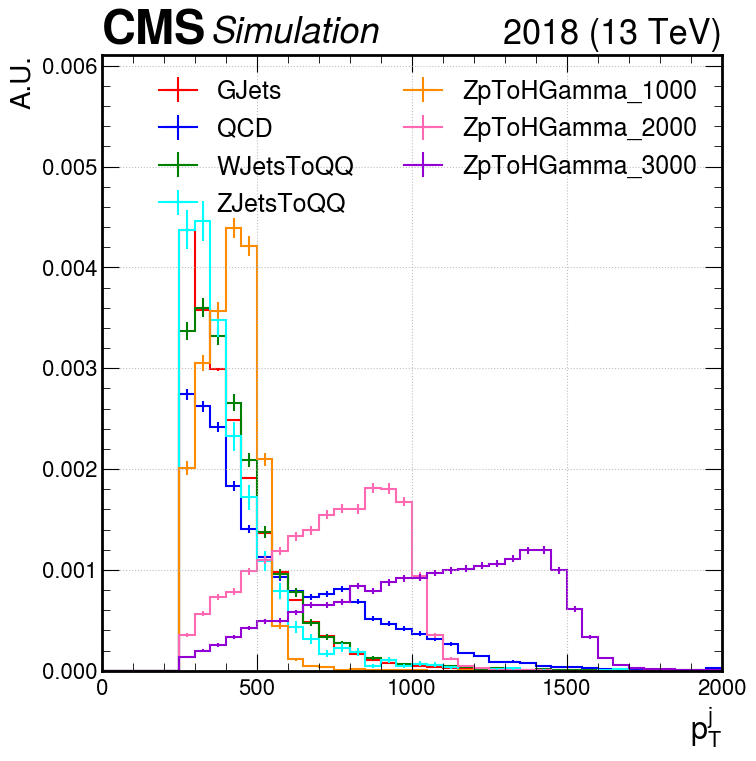

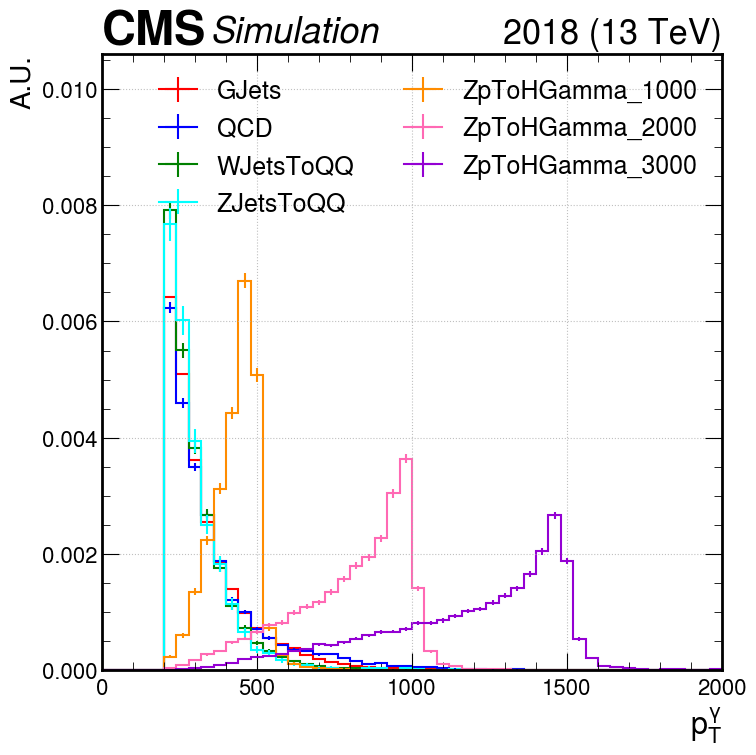

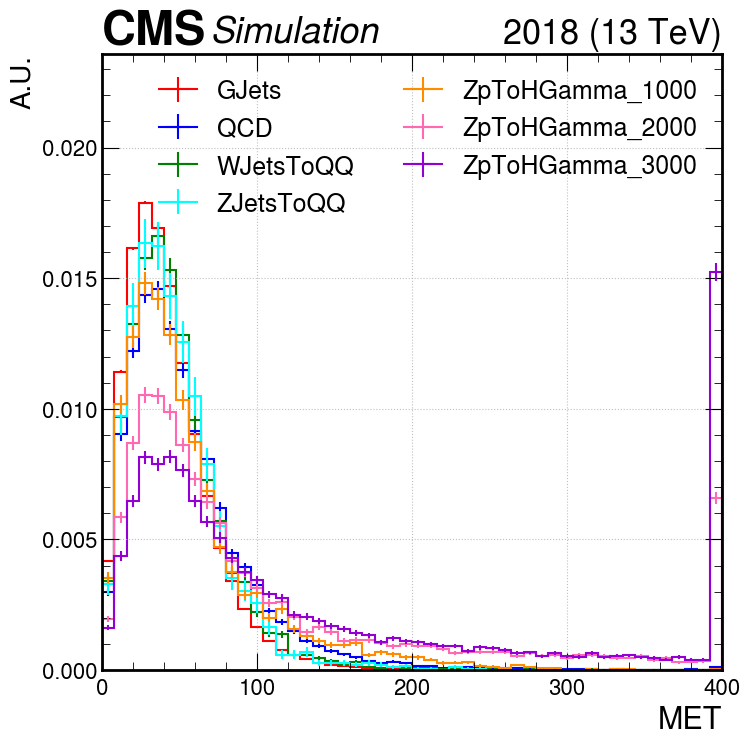

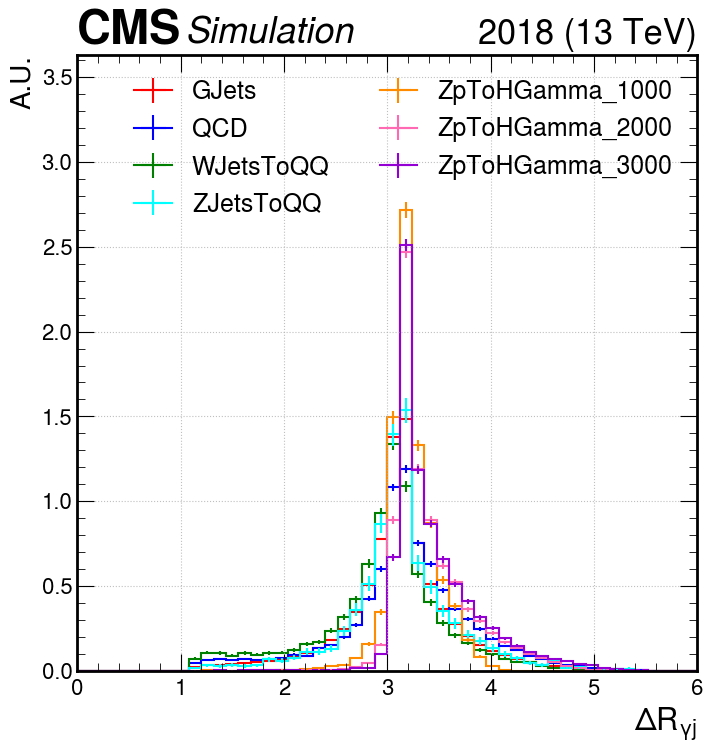

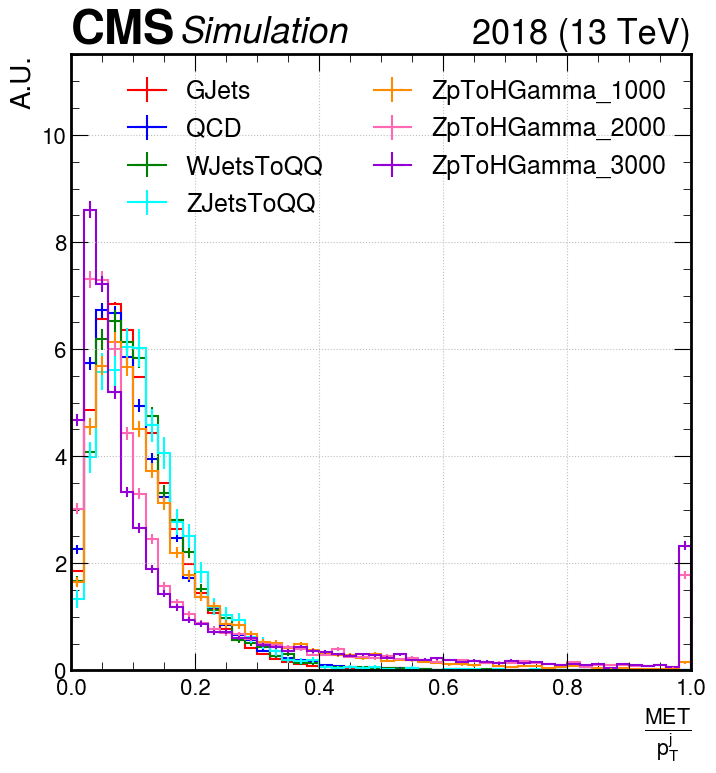

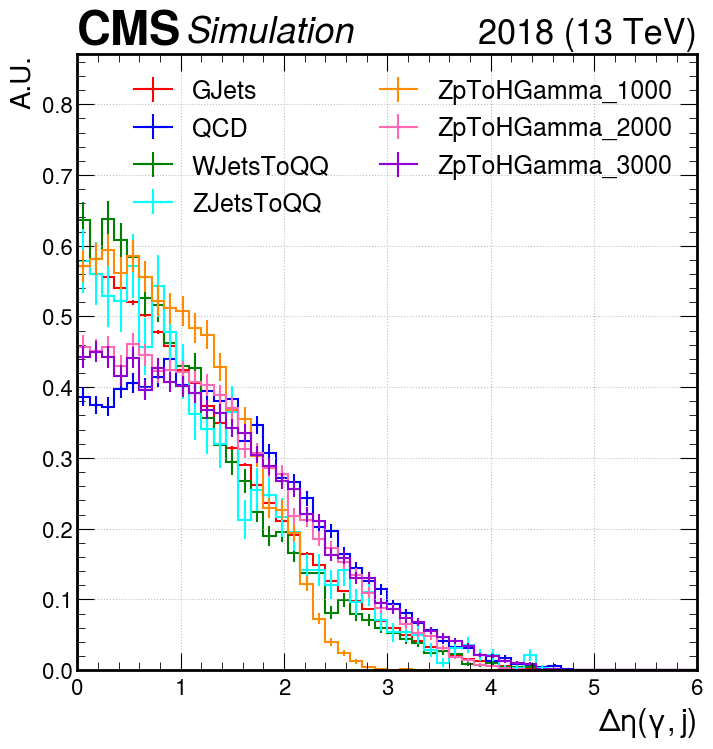

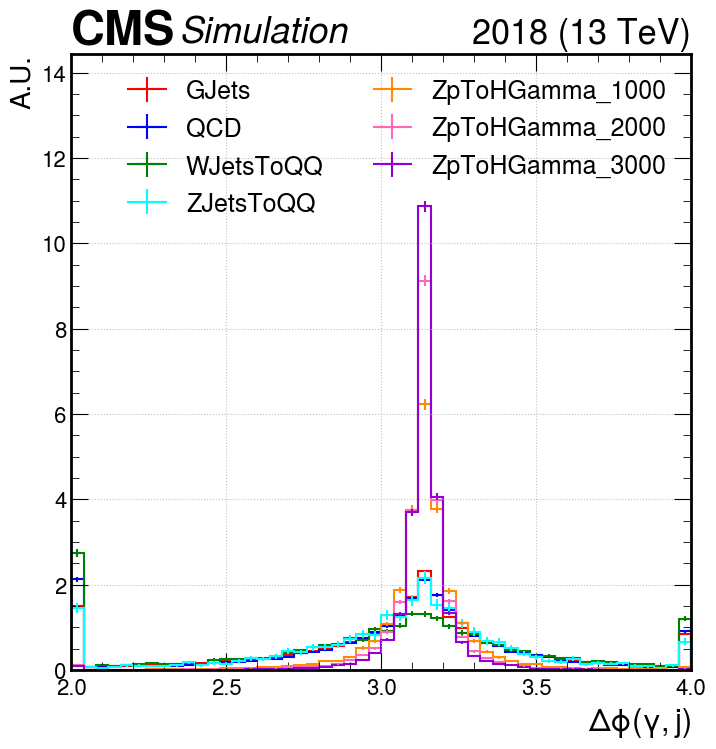

In [43]:
arrays={c: events[c]['photon-jet_mass'] for c in events}
plot(arrays, x_name=r'$m_{j\gamma}$', x_max=3500, bins=35)
arrays={c: events[c]['photon-jet_pt'] for c in events}
plot(arrays, x_name=r'$p_T^{\gamma j}$', x_max=1000, bins=50)
arrays={c: events[c]['AK8jet_msoftdrop'] for c in events}
plot(arrays, x_name=r'$m_{SD}^{j}$', bins=30, x_max=300, year=2018)
arrays={c: events[c]['AK8jet_pt'] for c in events}
plot(arrays, x_name=r'$p_T^j$', bins=40, x_max=2000, density=True, stack=False, year=2018)
arrays={c: events[c]['photon_pt'] for c in events}
plot(arrays, x_name=r'$p_T^\gamma$', bins=50, x_max=2000, density=True, stack=False, year=2018)
arrays={c: events[c]['event_MET_pt'] for c in events}
plot(arrays, x_name='MET', bins=50, x_max=400, year=2018)
arrays={c: events[c]['photon-jet_deltaR'] for c in events}
plot(arrays, x_name=r'$\Delta R_{\gamma j}$', bins=50, x_max=6, density=True, stack=False, year=2018)
arrays={c: events[c]['event_MET_pt']/events[c]['AK8jet_pt'] for c in events}
plot(arrays, x_name=r'$\frac{MET}{p_T^{j}}$', bins=50, x_max=1, density=True, stack=False, year=2018)
arrays={c: abs(events[c]['AK8jet_eta'] - events[c]['photon_eta']) for c in events}
plot(arrays, x_name=r'$|\Delta\eta(\gamma, j)|$', bins=50, x_max=6, year=2018)
arrays={c: abs(events[c]['AK8jet_phi'] - events[c]['photon_phi']) for c in events}
plot(arrays, x_name=r'$|\Delta\phi(\gamma, j)|$', bins=50, x_min=2, x_max=4, year=2018, underflow=True)
#arrays={c: events[c]['gen_HWW_decay_mode'] for c in events if 'gen_HWW_decay_mode' in events[c].fields}
#plot(arrays, x_name=r'gen_HWW_decay_mode', bins=18, x_min=2, x_max=20, density=True, stack=False, year=2018)